In [1]:
import sys
print(sys.executable)

e:\Learing\LLM\.venv\Scripts\python.exe


In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("dylanjcastillo/7k-books-with-metadata")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\adity\.cache\kagglehub\datasets\dylanjcastillo\7k-books-with-metadata\versions\3


In [3]:
import pandas as pd
books = pd.read_csv(f"{path}/books.csv")

In [5]:
books

,isbn13,isbn10,title,subtitle,authors,categories,thumbnail,description,published_year,average_rating,num_pages,ratings_count
0,9780002005883,0002005883,Gilead,NaN,Marilynne Robinson,Fiction,http://books.google.com/books/content?id=KQZCP...,A NOVEL THAT READERS and critics have been eag...,2004.0,3.85,247.0,361.0
1,9780002261982,0002261987,Spider's Web,A Novel,Charles Osborne;Agatha Christie,Detective and mystery stories,http://books.google.com/books/content?id=gA5GP...,A new 'Christie for Christmas' -- a full-lengt...,2000.0,3.83,241.0,5164.0
2,9780006163831,0006163831,The One Tree,NaN,Stephen R. Donaldson,American fiction,http://books.google.com/books/content?id=OmQaw...,Volume Two of Stephen Donaldson's acclaimed se...,1982.0,3.97,479.0,172.0
3,9780006178736,0006178731,Rage of angels,NaN,Sidney Sheldon,Fiction,http://books.google.com/books/content?id=FKo2T...,"A memorable, mesmerizing heroine Jennifer -- b...",1993.0,3.93,512.0,29532.0
4,9780006280897,0006280897,The Four Loves,NaN,Clive Staples Lewis,Christian life,http://books.google.com/books/content?id=XhQ5X...,Lewis' work on the nature of love divides love...,2002.0,4.15,170.0,33684.0
...,...,...,...,...,...,...,...,...,...,...,...,...
6805,9788185300535,8185300534,I Am that,Talks with Sri Nisargadatta Maharaj,Sri Nisargadatta Maharaj;Sudhakar S. Dikshit,Philosophy,http://books.google.com/books/content?id=Fv_JP...,This collection of the timeless teachings of o...,1999.0,4.51,531.0,104.0
6806,9788185944609,8185944601,Secrets Of The Heart,NaN,Khalil Gibran,Mysticism,http://books.google.com/books/content?id=XcrVp...,NaN,1993.0,4.08,74.0,324.0
6807,9788445074879,8445074873,Fahrenheit 451,NaN,Ray Bradbury,Book burning,NaN,NaN,2004.0,3.98,186.0,5733.0
6808,9789027712059,9027712050,The Berlin Phenomenology,NaN,Georg Wilhelm Friedrich Hegel,History,http://books.google.com/books/content?id=Vy7Sk...,Since the three volume edition ofHegel's Philo...,1981.0,0.00,210.0,0.0


In [6]:
books.describe(include='all').T # T for transpose 

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
isbn13,6810.0,NaN,NaN,NaN,9780676621541.416016,606891056.586608,9780002005883.0,9780330341506.0,9780553108095.5,9780809982553.5,9789042003408.0
isbn10,6810,6810,0002005883,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
title,6810,6398,The Lord of the Rings,11,NaN,NaN,NaN,NaN,NaN,NaN,NaN
subtitle,2381,2009,A Novel,226,NaN,NaN,NaN,NaN,NaN,NaN,NaN
authors,6738,3780,Agatha Christie,37,NaN,NaN,NaN,NaN,NaN,NaN,NaN
categories,6711,567,Fiction,2588,NaN,NaN,NaN,NaN,NaN,NaN,NaN
thumbnail,6481,6481,http://books.google.com/books/content?id=KQZCP...,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
description,6548,6474,No Marketing Blurb,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN
published_year,6804.0,NaN,NaN,NaN,1998.630364,10.484257,1853.0,1996.0,2002.0,2005.0,2019.0
average_rating,6767.0,NaN,NaN,NaN,3.933284,0.331352,0.0,3.77,3.96,4.13,5.0


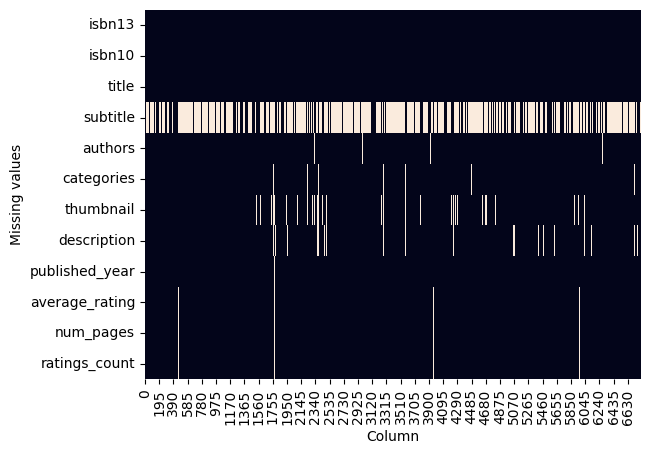

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

ax = plt.axes()
sns.heatmap(books.isna().transpose(), cbar=False, ax=ax)

plt.xlabel("Column")
plt.ylabel("Missing values")
plt.show()

In [8]:
import numpy as np

books["missing_description"]= np.where(books["description"].isna(), 1, 0)
books["age_of_book"] = 2025 - books["published_year"]

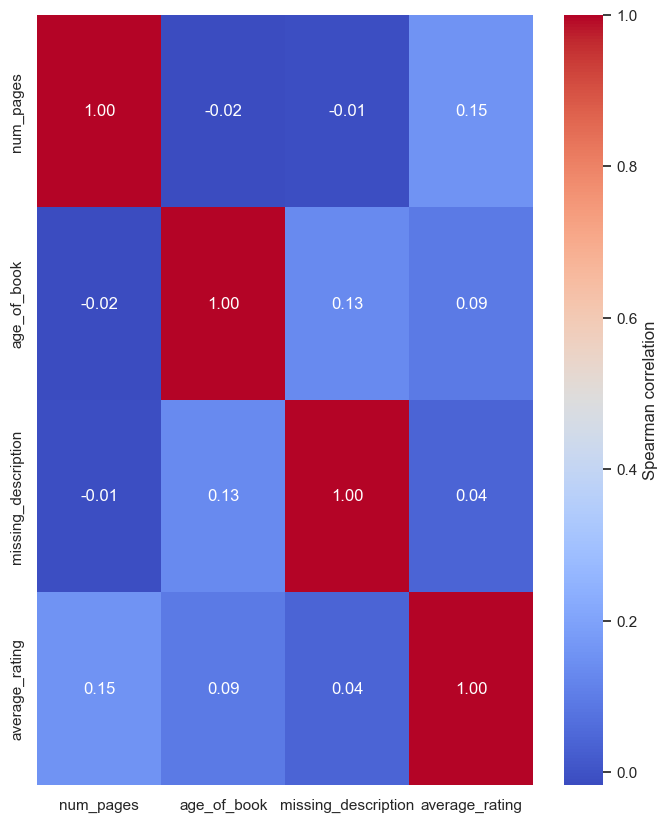

In [15]:
columns_of_interest = ["num_pages", "age_of_book","missing_description","average_rating"]
correlation_matrix = books[columns_of_interest].corr(method = "spearman")

sns.set_theme(style="white")
plt.figure(figsize=(8,10))
heatmap = sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar_kws={"label":"Spearman correlation"})
plt.show()

In [18]:
books_with_data = books[~(books["description"].isna()) &
                     ~(books["num_pages"].isna()) &
                     ~(books["published_year"].isna())]

In [25]:
# books_with_data.describe(include="all").T
books_with_data.T

,0,1,2,3,4,5,6,7,8,9,...,6797,6799,6800,6801,6802,6803,6804,6805,6808,6809
isbn13,9780002005883,9780002261982,9780006163831,9780006178736,9780006280897,9780006280934,9780006353287,9780006380832,9780006470229,9780006472612,...,9784770028969,9788122200850,9788125026600,9788171565641,9788172235222,9788173031014,9788179921623,9788185300535,9789027712059,9789042003408
isbn10,0002005883,0002261987,0006163831,0006178731,0006280897,0006280935,0006353282,0006380832,000647022X,0006472613,...,4770028962,8122200850,8125026606,8171565646,8172235224,8173031010,817992162X,8185300534,9027712050,9042003405
title,Gilead,Spider's Web,The One Tree,Rage of angels,The Four Loves,The Problem of Pain,An Autobiography,Empires of the Monsoon,The Gap Into Madness,Master of the Game,...,Coin Locker Babies,"Cry, the Peacock",Nietzsche For Beginners,Aspects of the Novel,Mistaken Identity,Journey to the East,The Monk Who Sold His Ferrari: A Fable About F...,I Am that,The Berlin Phenomenology,'I'm Telling You Stories'
subtitle,NaN,A Novel,NaN,NaN,NaN,NaN,NaN,A History of the Indian Ocean and Its Invaders,Chaos and Order,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Talks with Sri Nisargadatta Maharaj,NaN,Jeanette Winterson and the Politics of Reading
authors,Marilynne Robinson,Charles Osborne;Agatha Christie,Stephen R. Donaldson,Sidney Sheldon,Clive Staples Lewis,Clive Staples Lewis,Agatha Christie,Richard Hall,Stephen R. Donaldson,Sidney Sheldon,...,村上龍,Anita Desai,Marc Sautet,E. M. Forster,Nayantara Sahgal,Hermann Hesse,Robin Sharma,Sri Nisargadatta Maharaj;Sudhakar S. Dikshit,Georg Wilhelm Friedrich Hegel,Helena Grice;Tim Woods
categories,Fiction,Detective and mystery stories,American fiction,Fiction,Christian life,Christian life,"Authors, English","Africa, East","Hyland, Morn (Fictitious character)",Adventure stories,...,Fiction,Fiction,NaN,English fiction,Indic fiction (English),Adventure stories,Health & Fitness,Philosophy,History,Literary Criticism
thumbnail,http://books.google.com/books/content?id=KQZCP...,http://books.google.com/books/content?id=gA5GP...,http://books.google.com/books/content?id=OmQaw...,http://books.google.com/books/content?id=FKo2T...,http://books.google.com/books/content?id=XhQ5X...,http://books.google.com/books/content?id=Kk-uV...,http://books.google.com/books/content?id=c49GQ...,http://books.google.com/books/content?id=MuPEQ...,http://books.google.com/books/content?id=4oXav...,http://books.google.com/books/content?id=TkTYp...,...,http://books.google.com/books/content?id=87DJw...,http://books.google.com/books/content?id=_QKwV...,http://books.google.com/books/content?id=fPIv8...,http://books.google.com/books/content?id=qWU9P...,http://books.google.com/books/content?id=q-tKP...,http://books.google.com/books/content?id=rq6JP...,http://books.google.com/books/content?id=c_7mf...,http://books.google.com/books/content?id=Fv_JP...,http://books.google.com/books/content?id=Vy7Sk...,http://books.google.com/books/content?id=2lVyR...
description,A NOVEL THAT READERS and critics have been eag...,A new 'Christie for Christmas' -- a full-lengt...,Volume Two of Stephen Donaldson's acclaimed se...,"A memorable, mesmerizing heroine Jennifer -- b...",Lewis' work on the nature of love divides love...,"""In The Problem of Pain, C.S. Lewis, one of th...",Donation.,Until Vasco da Gama discovered the sea-route t...,A new-cover reissue of the fourth book in the ...,Kate Blackwell is an enigma and one of the mos...,...,Rescued from the lockers in which they were le...,This book is the story of a young girl obsesse...,Not only does Nietzsche for Beginners delve in...,"Forster's lively, informed originality and wit...",On A Train Journey Home To North India After L...,This book tells the tale of a man who goes on ...,"Wisdom to Create a Life of Passion, Purpose, a...",This collection of the timeless teachings of o...,Since the three volume edition ofHegel's Philo...,This is a jubilant and rewarding collection of...
published_year,2004.0,2000.0,1982.0,1993.0,2002.0,200

In [27]:
books_with_data["categories"].value_counts().reset_index().sort_values("count", ascending=False)

,categories,count
0,Fiction,2523
1,Juvenile Fiction,534
2,Biography & Autobiography,391
3,History,258
4,Literary Criticism,164
...,...,...
526,Meditation,1
527,Gay men,1
528,Christian fiction,1
529,"Napoleonic Wars, 1800-1815",1
